In [1]:
import numpy as np
from infer import style_transfer

Loaded checkpoint: model_iter50000.pth


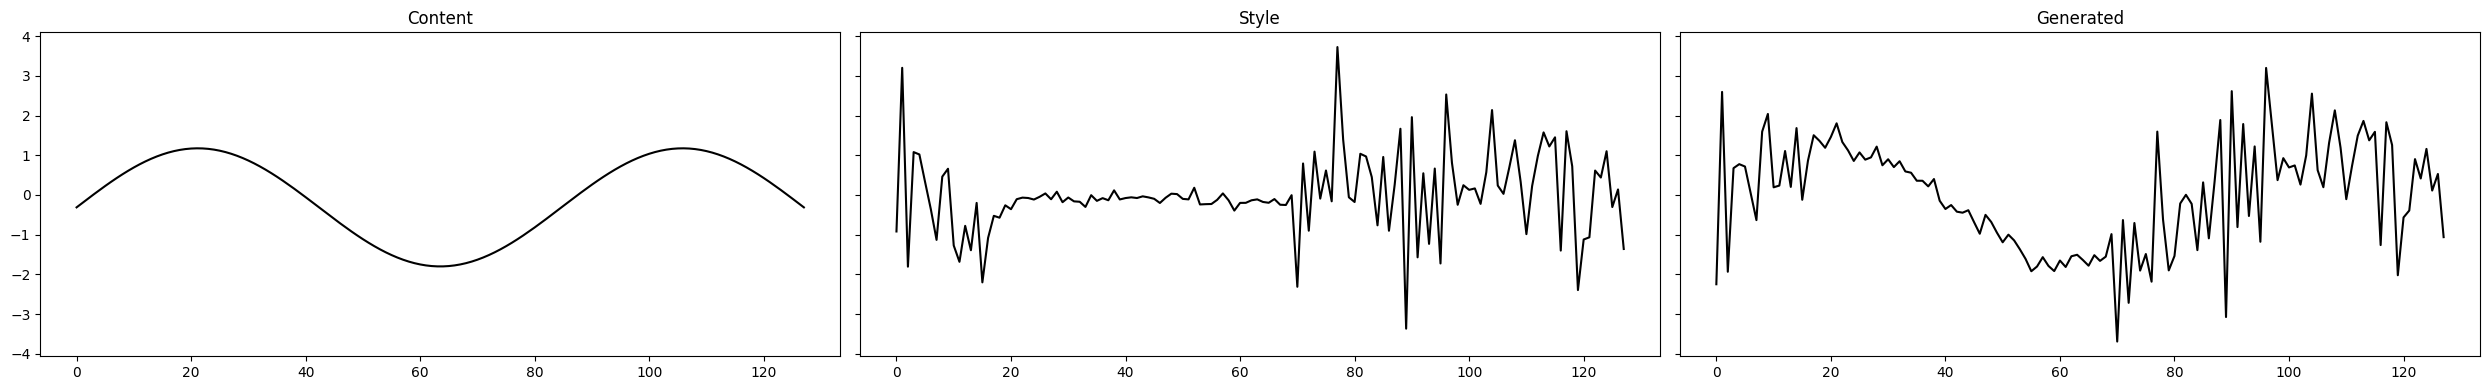

In [2]:
x = np.linspace(0, 3 * np.pi, 128)
content = np.sin(x)
style = np.random.randn(128)
style[20:70] = np.random.randn(50) * 0.1

result = style_transfer(
    style_series=style,
    content_series=content,
    denorm="none",     # "content", "style", or "none"
    num_steps=500,         # diffusion steps
    c_c=1.0,               # content weight
    c_s=0.0,               # style-content weight
)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(25, 4), sharey=True)
ax[0].plot(result["normalized_content"], color="black")
ax[0].set_title("Content")
ax[1].plot(result["normalized_style"], color="black")
ax[1].set_title("Style")
ax[2].plot(result["denorm"], color="black")
ax[2].set_title("Generated")
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Saved plot to: /Users/mayank/Downloads/electric_device_detection_timeseries.pdf


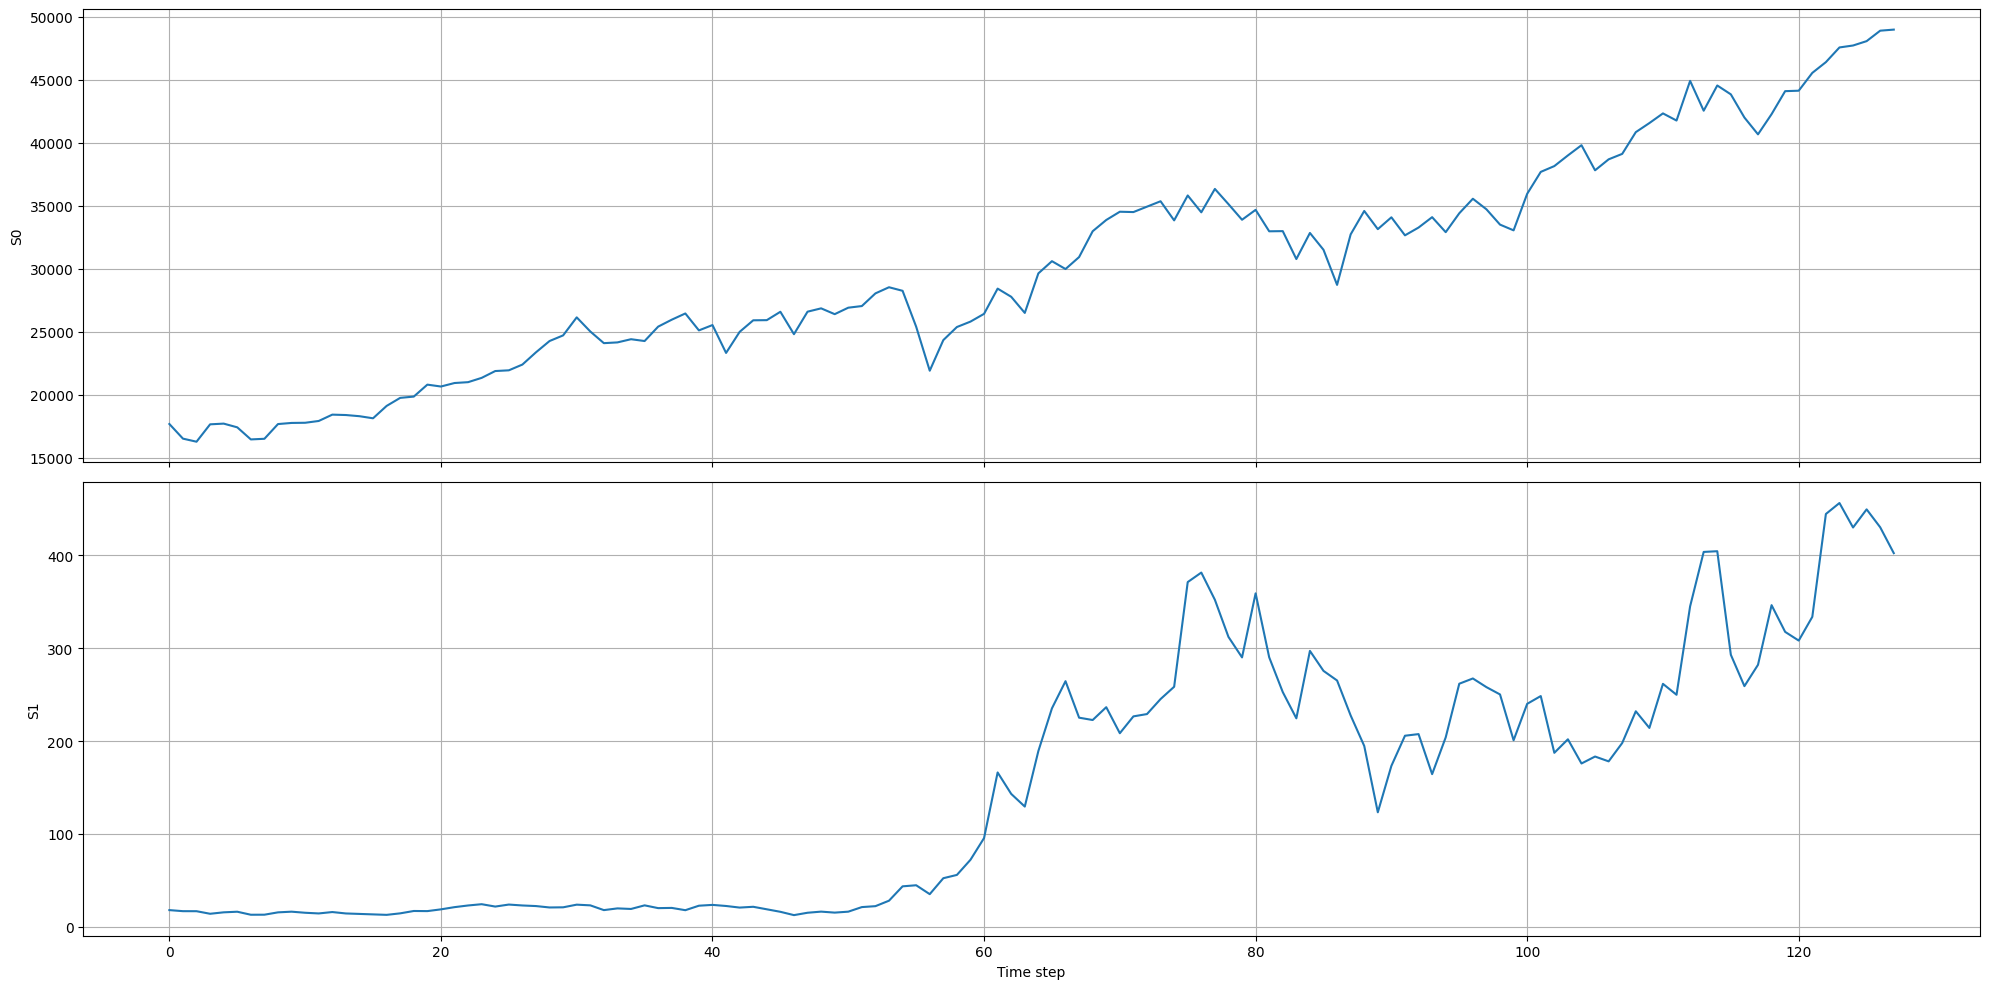

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path
import yfinance as yf
import numpy as np

# Download Apple stock data
start = "2015-01-01"
end = "2026-03-01"
interval = "1mo"
stock_1 = "^DJI"  # Dow Jones Industrial Average
stock_2 = "TSLA"  # Tesla, Inc.
data = yf.download(stock_1, start=start, end=end, interval=interval)
dax_data=data["Close"].values.squeeze()
data = yf.download(stock_2, start=start, end=end, interval=interval)
tsla_data = data["Close"].values.squeeze()
X = np.stack([dax_data[-128:],tsla_data[-128:]])
np.save(Path.home() / "Downloads" / f"{stock_1}_{stock_2}_{start}_{end}_{interval}.npy", X)
# X, y = load_classification("SharePriceIncrease")
# print(" Shape of X = ", X.shape)

# X=X.squeeze()  # Remove the singleton dimension

number_of_timeseries=2
fig, axes = plt.subplots(number_of_timeseries, 1, figsize=(20, number_of_timeseries*5), sharex=True)

for i in range(number_of_timeseries):
    axes[i].plot(X[i, :128])
    axes[i].set_ylabel(f"S{i}")
    axes[i].grid(True)

axes[-1].set_xlabel("Time step")

plt.tight_layout()
output_path = Path.home() / "Downloads" / "electric_device_detection_timeseries.pdf"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {output_path}")
plt.show()

Loaded checkpoint: model_iter50000.pth


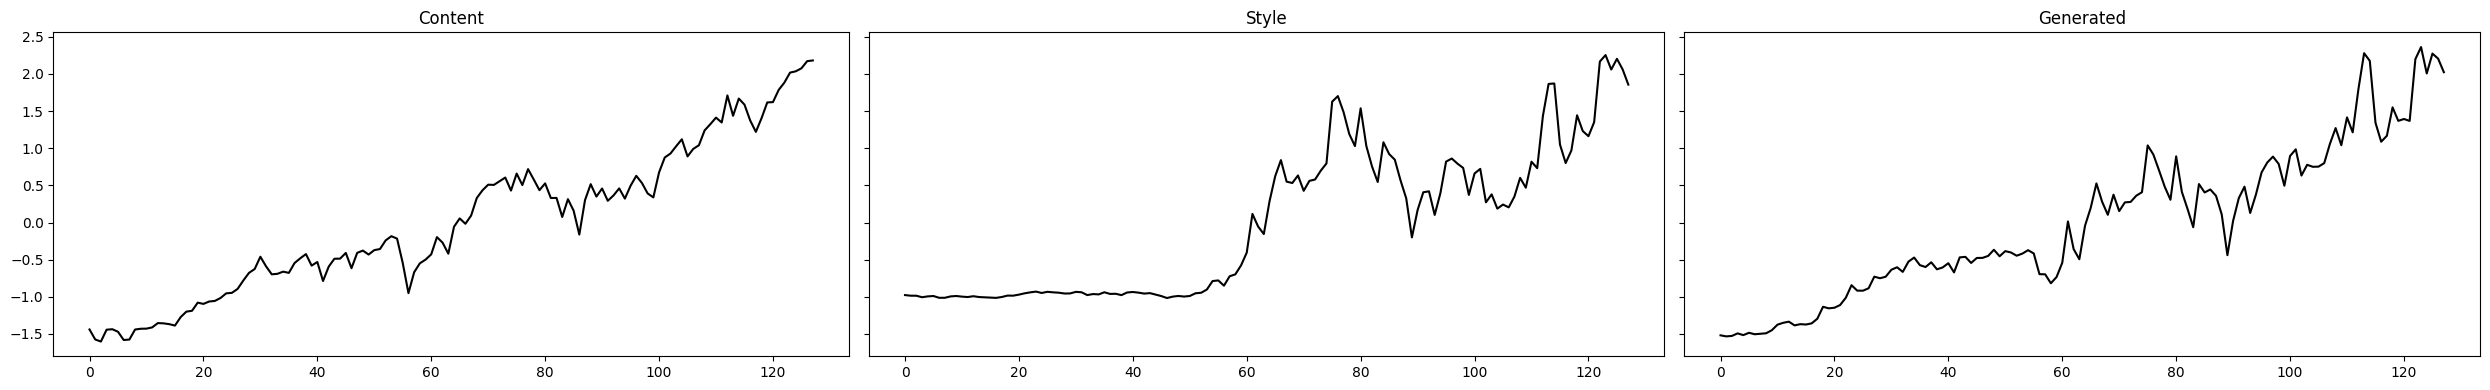

In [4]:
style_transfer_stock = style_transfer(
    style_series=X[1, :128],
    content_series=X[0, :128],
    denorm="none",     # "content", "style", or "none"
    num_steps=500,         # diffusion steps
    c_c=1.0,               # content weight
    c_s=0.0,               # style-content weight
)
# plot the results
fig, ax = plt.subplots(1, 3, figsize=(25, 4), sharey=True)
ax[0].plot(style_transfer_stock["normalized_content"], color="black")
ax[0].set_title("Content")
ax[1].plot(style_transfer_stock["normalized_style"], color="black")
ax[1].set_title("Style")
ax[2].plot(style_transfer_stock["denorm"], color="black")
ax[2].set_title("Generated")
plt.tight_layout()
plt.show()

Loaded checkpoint: model_iter50000.pth
Loaded checkpoint: model_iter50000.pth


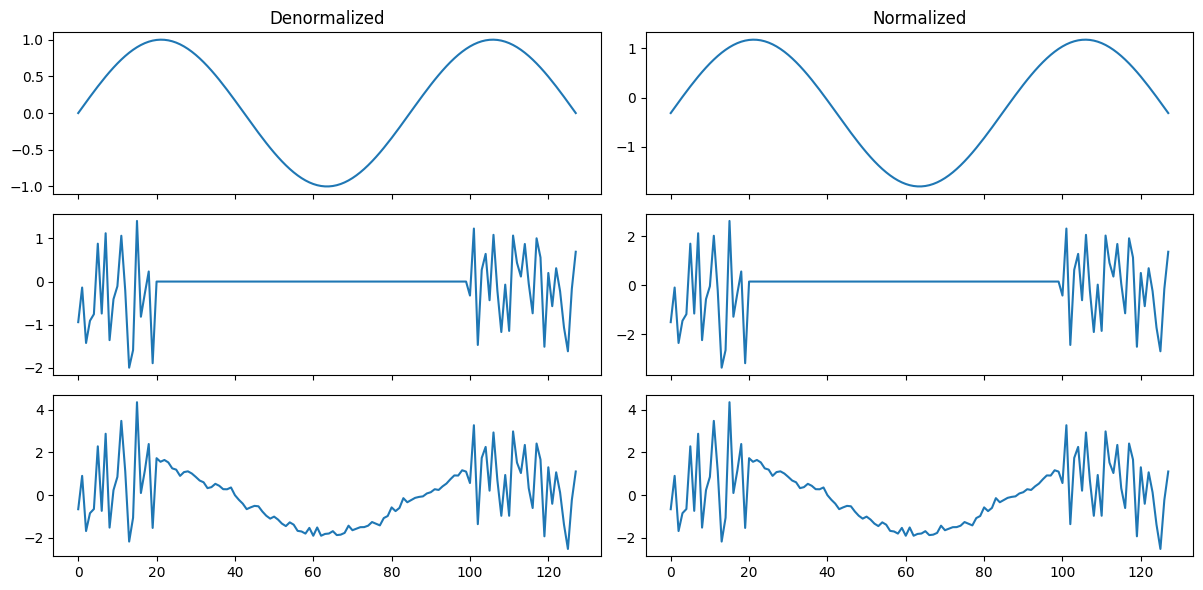

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from infer import style_transfer

input = "sine"

if input == "sine":
    # Example input (must be length 128)
    x = np.linspace(0, 3 * np.pi, 128)
    content = np.sin(x)
    #n = 128
    style = np.concatenate(
        [
            np.random.randn(20) * 1,
            np.random.randn(80) * 0,
            np.random.randn(28) * 1,
        ]
    )
    input = Path.home() / "Downloads" / "sine.npy"
else:
    input_series = np.load(input)
    content = input_series[0, :128]  # Use the first time series as
    style = input_series[1, :128]  # Use the second time series as

result = style_transfer(
    style_series=style,
    content_series=content,
    denorm="none",     # "content", "style", or "none"
    num_steps=500,         # diffusion steps
    c_c=1.0,               # content weight
    c_s=0.0,               # style-content weight
)

result_2 = style_transfer(
    style_series=style,
    content_series=content,
    denorm="none",     # "content", "style", or "none"
    num_steps=500,         # diffusion steps
    c_c=1.0,               # content weight
    c_s=0.0,               # style-content weight
)


result_array = {"content_norm": result["normalized_content"],
                "style_norm": result["normalized_style"],
                "generated_norm_1": result["normalized_generated"],
                "generated_norm_2": result_2["normalized_generated"]}
np.save(Path(input).with_name(Path(input).stem + "_transferred.npy"), result_array)

fig, axes = plt.subplots(3, 2, figsize=(12, 6), sharex=True)

# Column titles
axes[0, 0].set_title("Denormalized")
axes[0, 1].set_title("Normalized")

# Row 1: content
axes[0, 0].plot(content, label="content_denorm")
axes[0, 1].plot(result["normalized_content"], label="content_norm")

# Row 2: style
axes[1, 0].plot(style, label="style_denorm")
axes[1, 1].plot(result["normalized_style"], label="style_norm")

# Row 3: generated
axes[2, 0].plot(result["denorm"])
axes[2, 1].plot(result["normalized_generated"], label="generated_norm")

# Use one shared y-range across all subplots.
all_series = [
    content,
    result["normalized_content"],
    style,
    result["normalized_style"],
    result["denorm"],
    result["normalized_generated"],
]
# ymin = min(np.min(series) for series in all_series)
# ymax = max(np.max(series) for series in all_series)

# for r in range(3):
#     for c in range(2):
#         axes[r, c].set_ylim(ymin, ymax)
#         axes[r, c].legend()
#         axes[r, c].grid(True)

plt.tight_layout()
plt.show()